In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ziyadaltalhi/youtube-data/YouTube Datasets - After Processing/المنطقة الوسطى/Youtube Data/القصيم/dataset_youtube-comments-scraper_2025-11-13_07-31-25-109_textready_analysis.xlsx
/kaggle/input/datasets/ziyadaltalhi/youtube-data/YouTube Datasets - After Processing/المنطقة الوسطى/Youtube Data/القصيم/dataset_youtube-comments-scraper_2025-11-13_07-06-14-938_textready_cleaned.xlsx
/kaggle/input/datasets/ziyadaltalhi/youtube-data/YouTube Datasets - After Processing/المنطقة الوسطى/Youtube Data/القصيم/dataset_youtube-comments-scraper_2025-11-11_07-18-20-122_textready_cleaned.xlsx
/kaggle/input/datasets/ziyadaltalhi/youtube-data/YouTube Datasets - After Processing/المنطقة الوسطى/Youtube Data/القصيم/dataset_youtube-comments-scraper_2025-11-11_08-03-55-015_textready_cleaned.xlsx
/kaggle/input/datasets/ziyadaltalhi/youtube-data/YouTube Datasets - After Processing/المنطقة الوسطى/Youtube Data/القصيم/dataset_youtube-comments-scraper_2025-11-11_07-55-12-414_textready_cleaned.xlsx

In [2]:
import os, glob, re, pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix,f1_score
from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import ReduceLROnPlateau

2026-04-19 09:34:12.782331: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776591253.166138      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776591253.281620      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776591254.300815      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776591254.300867      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776591254.300870      55 computation_placer.cc:177] computation placer alr

In [3]:
# =========================================================
# (0) PATH + SETTINGS  (ALL REGIONS) + QUICK STRUCTURE CHECK
# =========================================================
ALL_REGIONS_ROOT = "/kaggle/input/datasets/ziyadaltalhi/youtube-data/YouTube Datasets - After Processing/"
TEXT_COL = "Text_TR"  # ✅ العمود المراد العمل عليه
STAR_CANDIDATES = {"stars", "Stars"}
print("\n[STEP 0] Path checks (ALL REGIONS)")
print("Root exists:", os.path.exists(ALL_REGIONS_ROOT))
print("Root is dir:", os.path.isdir(ALL_REGIONS_ROOT))

region_dirs = sorted([d for d in glob.glob(os.path.join(ALL_REGIONS_ROOT, "*")) if os.path.isdir(d)])
print("Region folders found:", len(region_dirs))
print("Regions:", [os.path.basename(d) for d in region_dirs])

# عرض سريع لأول 3 مناطق: عدد المدن داخل كل منطقة
for rd in region_dirs[:3]:
    city_dirs = sorted([d for d in glob.glob(os.path.join(rd, "*")) if os.path.isdir(d)])
    print(f"  - {os.path.basename(rd)}: cities={len(city_dirs)} (sample: {[os.path.basename(x) for x in city_dirs[:5]]})")



[STEP 0] Path checks (ALL REGIONS)
Root exists: True
Root is dir: True
Region folders found: 5
Regions: ['المنطقة الجنوبية', 'المنطقة الشرقية', 'المنطقة الشمالية', 'المنطقة الغربية', 'المنطقة الوسطى']
  - المنطقة الجنوبية: cities=4 (sample: ['بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة', 'بيانات اليوتيوب لمنطقة جازان - بعد المعالجة', 'بيانات اليوتيوب لمنطقة عسير - بعد المعالجة', 'بيانات اليوتيوب لمنطقة نجران - بعد المعالجة'])
  - المنطقة الشرقية: cities=1 (sample: ['بيانات اليوتيوب للشرقية - بعد المعالجة'])
  - المنطقة الشمالية: cities=1 (sample: ['( المنطقة الشمالية ) Youtube Data -  After Preproccesing'])


In [4]:
# =========================================================
# Helpers: extract region name (inside parentheses) + city
# =========================================================
PAREN_RE = re.compile(r"\((.*?)\)")

def extract_region_from_folder(region_folder_name: str) -> str:
    """
    يستخرج النص بين ( ) من اسم مجلد المنطقة.
    مثال: "( المنطقة الغربية ) Google Maps Data - After Cleaning" -> "المنطقة الغربية"
    إذا لم توجد أقواس يرجع اسم المجلد نفسه.
    """
    m = PAREN_RE.search(region_folder_name)
    if m:
        return m.group(1).strip()
    return region_folder_name.strip()

def list_region_folders(root_folder: str):
    region_dirs = sorted([d for d in glob.glob(os.path.join(root_folder, "*")) if os.path.isdir(d)])
    return region_dirs

def list_city_folders(region_dir: str):
    return sorted([d for d in glob.glob(os.path.join(region_dir, "*")) if os.path.isdir(d)])

def list_files_in_city(city_dir: str):
    return (
        glob.glob(os.path.join(city_dir, "*.xlsx")) +
        glob.glob(os.path.join(city_dir, "*.xls")) +
        glob.glob(os.path.join(city_dir, "*.csv"))
    )

def read_any_file(path: str) -> pd.DataFrame:
    ext = os.path.splitext(path)[1].lower()
    if ext in [".xlsx", ".xls"]:
        df = pd.read_excel(path)
    elif ext == ".csv":
        # ترميزات عربية شائعة
        try:
            df = pd.read_csv(path, encoding="utf-8")
        except UnicodeDecodeError:
            try:
                df = pd.read_csv(path, encoding="utf-8-sig")
            except UnicodeDecodeError:
                df = pd.read_csv(path, encoding="cp1256")
    else:
        raise ValueError(f"Unsupported extension: {ext}")
    df.columns = [str(c).strip() for c in df.columns]
    return df

def standardize_star_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    - يقبل Stars / stars / ... ويوحّدها إلى عمود اسمه 'Stars' إن وجد.
    - لا يغير القيم الآن.
    """
    colmap = {c.lower(): c for c in df.columns}
    # إذا موجود Stars بالاسم الصحيح خلاص
    if "Stars" in df.columns:
        return df

    # ابحث عن أي عمود اسمه stars case-insensitive
    if "stars" in colmap:
        df = df.rename(columns={colmap["stars"]: "Stars"})
        return df

    # مرونة إضافية: إذا فيه rating مثلا
    for cand in list(STAR_CANDIDATES):
        key = cand.lower()
        if key in colmap:
            df = df.rename(columns={colmap[key]: "Stars"})
            return df

    return df  # لم نجد عمود نجوم

In [5]:
import os
import pandas as pd



# =========================================================
# (1) GET ALL VALID FILES (RECURSIVE)
# =========================================================
def get_analysis_files_recursive(region_path):
    files = []

    for root, dirs, filenames in os.walk(region_path):
        for fname in filenames:
            name = fname.lower()
            fpath = os.path.join(root, fname)

            if (
                name.endswith((".xlsx", ".xls")) and
                "analysis" in name and
                "summary" not in name
            ):
                files.append(fpath)

    return files


# =========================================================
# (2) SCAN AVAILABILITY
# =========================================================
def scan_availability(root_folder: str):
    rows = []

    for rd in list_region_folders(root_folder):
        region_folder = os.path.basename(rd)
        region_name = extract_region_from_folder(region_folder)

        files = get_analysis_files_recursive(rd)

        rows.append({
            "Region_Folder": region_folder,
            "Region_Name": region_name,
            "Files": len(files),
            "Sample_File": files[0] if files else None
        })

    return pd.DataFrame(rows).sort_values("Files", ascending=False).reset_index(drop=True)


# =========================================================
# (3) READ ALL REGIONS (CHUNKED)
# =========================================================
def read_all_regions_chunked(root_folder: str, max_files_per_region=None, keep_columns=None):

    all_frames = []
    report_rows = []

    region_dirs = list_region_folders(root_folder)

    for r_idx, rd in enumerate(region_dirs, 1):
        region_folder = os.path.basename(rd)
        region_name = extract_region_from_folder(region_folder)

        region_files = get_analysis_files_recursive(rd)

        if max_files_per_region is not None:
            region_files = region_files[:max_files_per_region]

        print(f"\n[STEP 1] Region {r_idx}/{len(region_dirs)}: {region_name} | files={len(region_files)}")

        n_rows_region = 0
        has_text = 0
        has_stars = 0
        read_ok = 0
        read_err = 0

        for i, p in enumerate(region_files, 1):
            try:
                df = read_any_file(p)
                df = standardize_star_column(df)

                # استخراج اسم المدينة بشكل ذكي
                city_name = os.path.basename(os.path.dirname(p))
                if city_name.startswith("Tik_"):
                    city_name = os.path.basename(os.path.dirname(os.path.dirname(p)))

                df["Region_Folder"] = region_folder
                df["Region_Name"] = region_name
                df["City_Folder"] = city_name
                df["Source_File"] = os.path.basename(p)
                df["__path__"] = p

                # تحقق من الأعمدة
                if TEXT_COL in df.columns:
                    has_text += 1
                if "Stars" in df.columns:
                    has_stars += 1


                # تقليل الأعمدة (اختياري)
                if keep_columns is not None:
                    keep = [c for c in keep_columns if c in df.columns]
                    meta = ["Region_Folder","Region_Name","City_Folder","Source_File","__path__"]
                    keep = list(dict.fromkeys(keep + meta))
                    df = df[keep].copy()

                n_rows_region += len(df)
                all_frames.append(df)
                read_ok += 1

                if i <= 2:
                    print(f"  sample file [{i}] {region_name}/{city_name}/{os.path.basename(p)} rows={len(df)}")

                if i % 50 == 0:
                    print(f"  progress: {i}/{len(region_files)} files")

            except Exception as e:
                read_err += 1
                print(f"❌ Error reading: {p}")

        report_rows.append({
            "Region_Name": region_name,
            "Region_Folder": region_folder,
            "Files_Read_OK": read_ok,
            "Files_Read_Err": read_err,
            "Files_with_Text": has_text,
            "Files_with_Stars": has_stars,
            "Total_Rows_This_Region": n_rows_region
        })

    df_region_report = pd.DataFrame(report_rows) \
        .sort_values("Total_Rows_This_Region", ascending=False) \
        .reset_index(drop=True)

    df_all = pd.concat(all_frames, ignore_index=True) if all_frames else pd.DataFrame()

    return df_all, df_region_report


# =========================================================
# (4) RUN
# =========================================================

print("\n[STEP 1A] Availability per region:")
df_av = scan_availability(ALL_REGIONS_ROOT)
display(df_av)

KEEP_COLS = [
    TEXT_COL,
    "Stars",
    
]

df1, df_region_report = read_all_regions_chunked(
    ALL_REGIONS_ROOT,
    max_files_per_region=None,
    keep_columns=KEEP_COLS
)

print("\n[STEP 1B] Column availability per region:")
display(df_region_report)

print("\n[STEP 1 RESULT] df1 shape:", df1.shape)
print("Columns:", df1.columns.tolist())


[STEP 1A] Availability per region:


,Region_Folder,Region_Name,Files,Sample_File
0,المنطقة الجنوبية,المنطقة الجنوبية,82,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
1,المنطقة الوسطى,المنطقة الوسطى,47,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
2,المنطقة الشرقية,المنطقة الشرقية,46,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
3,المنطقة الشمالية,المنطقة الشمالية,20,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
4,المنطقة الغربية,المنطقة الغربية,3,/kaggle/input/datasets/ziyadaltalhi/youtube-da...



[STEP 1] Region 1/5: المنطقة الجنوبية | files=82
  sample file [1] المنطقة الجنوبية/بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة/Al-Baha Vedio Comments 18_textready_analysis.xlsx rows=26
  sample file [2] المنطقة الجنوبية/بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة/Al-Baha Vedio Comments 24_textready_analysis.xlsx rows=45
  progress: 50/82 files

[STEP 1] Region 2/5: المنطقة الشرقية | files=46
  sample file [1] المنطقة الشرقية/الجبيل/7_textready_analysis.xlsx rows=0
  sample file [2] المنطقة الشرقية/الجبيل/4_textready_analysis.xlsx rows=1

[STEP 1] Region 3/5: المنطقة الشمالية | files=20
  sample file [1] المنطقة الشمالية/تبوك/وادي الديسة_textready_analysis.xlsx rows=526
  sample file [2] المنطقة الشمالية/تبوك/تبوك_textready_analysis.xlsx rows=780

[STEP 1] Region 4/5: المنطقة الغربية | files=3
  sample file [1] المنطقة الغربية/مكة/معرض الوحي_textready_analysis.xlsx rows=56
  sample file [2] المنطقة الغربية/مكة/مكة مول_textready_analysis.xlsx rows=65

[STEP 1] Region 5/5: المنطقة الو

,Region_Name,Region_Folder,Files_Read_OK,Files_Read_Err,Files_with_Text,Files_with_Stars,Total_Rows_This_Region
0,المنطقة الجنوبية,المنطقة الجنوبية,82,0,82,82,9240
1,المنطقة الوسطى,المنطقة الوسطى,47,0,47,47,5097
2,المنطقة الشمالية,المنطقة الشمالية,20,0,20,20,4499
3,المنطقة الشرقية,المنطقة الشرقية,46,0,46,46,387
4,المنطقة الغربية,المنطقة الغربية,3,0,3,3,216



[STEP 1 RESULT] df1 shape: (19439, 7)
Columns: ['Text_TR', 'Stars', 'Region_Folder', 'Region_Name', 'City_Folder', 'Source_File', '__path__']


In [6]:
df1['Stars'].value_counts()

Stars
5    9930
1    6458
3    3051
Name: count, dtype: int64

In [7]:
# =========================================================
# (2) FILTER ONLY TRULY-EMPTY Text_TR (NaN + "" + "nan" + "[]" ...)
# =========================================================
print(f"\n[STEP 2] Using {TEXT_COL} + strong empty filter")

# ✅ الداتا الجديدة
if TEXT_COL not in df1.columns:
    raise ValueError(f"عمود {TEXT_COL} غير موجود في البيانات.")

before2 = len(df1)

# لا نحول إلى string الآن (مهم)
s = df1[TEXT_COL]

empty_like = {
    "", "nan", "NaN", "none", "None", "NONE",
    "<NA>", "[]", "[ ]", "{}", "null", "NULL"
}

empty_mask = (
    s.isna() |
    s.astype(str).str.strip().isin(empty_like)
)

empty_count = int(empty_mask.sum())

# ✅ الناتج الجديد
df2 = df1.loc[~empty_mask].copy()

# العمود الذي سيستخدم لاحقاً للمودل
df2["TEXT_FOR_MODEL"] = df2[TEXT_COL].astype(str).str.strip()

print("\n[STEP 2 RESULT]")
print("Rows before:", before2)
print("Empty-like rows:", empty_count)
print("Rows after:", len(df2))

print("\nSample empty-like values:")
print(s.loc[empty_mask].head(10).astype(str).tolist())


[STEP 2] Using Text_TR + strong empty filter

[STEP 2 RESULT]
Rows before: 19439
Empty-like rows: 0
Rows after: 19439

Sample empty-like values:
[]


In [8]:
import re
import pandas as pd

print("\n[STEP 4] Safe Cleaning (Text Only)")

TEXT_COL = "Text_TR"

if TEXT_COL not in df2.columns:
    raise ValueError(f"{TEXT_COL} غير موجود في df2")

# =========================
# Regex definitions
# =========================
AR_DIACRITICS_RE = re.compile(r"[\u0617-\u061A\u064B-\u0652\u0670]")
AR_TATWEEL_RE    = re.compile(r"\u0640")

# =========================
# Arabic normalization
# =========================
def normalize_arabic_safe(text: str) -> str:
    text = AR_DIACRITICS_RE.sub("", text)
    text = AR_TATWEEL_RE.sub("", text)
    text = re.sub(r"[إأآا]", "ا", text)
    return text

# =========================
# Main cleaning function
# =========================
def clean_text(s):
    if pd.isna(s):
        return ""

    s = str(s).strip().lower()
    if not s:
        return ""

    # remove links / emails / mentions / hashtags
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"\S+@\S+", " ", s)
    s = re.sub(r"@\w+", " ", s)
    s = re.sub(r"#\w+", " ", s)

    # remove emojis
    s = re.sub(r"[\U00010000-\U0010ffff]", " ", s)

    # keep Arabic / English / digits / spaces
    s = re.sub(r"[^0-9a-z\u0600-\u06FF\s]", " ", s)

    # normalize Arabic
    s = normalize_arabic_safe(s)

    # reduce repeated letters
    s = re.sub(r"(.)\1{2,}", r"\1\1", s)

    # collapse spaces
    s = re.sub(r"\s+", " ", s).strip()

    # remove numbers only
    if re.fullmatch(r"\d+", s):
        return ""

    return s


# =========================
# BEFORE cleaning view
# =========================
df_before_clean = df2[[TEXT_COL]].copy()
df_before_clean = df_before_clean.rename(columns={TEXT_COL: "text_before"})

display(df_before_clean.head(10))


# =========================
# Apply cleaning
# =========================
df4 = df2.copy()
df4["text_clean"] = df4[TEXT_COL].apply(clean_text)


# =========================
# Compare
# =========================
df_compare = pd.DataFrame({
    "text_before": df2[TEXT_COL],
    "text_clean": df4["text_clean"]
})

display(df_compare.head(20))


# =========================
# Removed rows
# =========================
df_removed = df_compare[df_compare["text_clean"].str.len() == 0]

print("Removed rows:", len(df_removed))
display(df_removed.head(20))


# =========================
# Final dataset
# =========================
df4 = df_compare[df_compare["text_clean"].str.len() > 0]

print("Final shape:", df4.shape)
display(df4.head(20))


# =========================
# Test examples
# =========================
print("\n[CHECK] examples:")
for t in ["سييييئ جدا", "المكان رائع!!!", "http://test.com", "12345", "مطعم جميل"]:
    print(t, "->", clean_text(t))


[STEP 4] Safe Cleaning (Independent)


,text_before,Stars,Region_Name,Region_Folder,City_Folder,Source_File,__path__
0,لقد عملت مدرسا في ثانوية رغدان لمدة خمس سنوات ...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
1,منتزه جميل ومخدوم ومنظم جئته قبل 40 سنة تقريبا...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
2,سبحان الله والحمد لله ولا اله الا الله والله اكبر,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
3,انا ام عندي 62سنة ابنتي عندها 19 سنة محبين الق...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
4,ماشاء الله اللهم صل وسلم وبارك علي سيدنا محمد ...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
5,ما شاء الله تبارك الرحمن المنطقة جمالها رائع ت...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
6,ماشاءالله تبارك الله عليك يا شيخنا الفاضل ايه ...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
7,١ نعم ٢ لا يوجد صعوبة ٣ نعم الاسعار غالية قليل...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
8,جزاك الله خير ياخوي محمد وبيض الله وجهك علي ما...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
9,الله يوفقك اخي في الله واسال الله العظيم رب ال...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...


,text_before,text_clean,Stars,Region_Name,Region_Folder,City_Folder,Source_File,__path__
0,لقد عملت مدرسا في ثانوية رغدان لمدة خمس سنوات ...,لقد عملت مدرسا في ثانوية رغدان لمدة خمس سنوات ...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
1,منتزه جميل ومخدوم ومنظم جئته قبل 40 سنة تقريبا...,منتزه جميل ومخدوم ومنظم جئته قبل 40 سنة تقريبا...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
2,سبحان الله والحمد لله ولا اله الا الله والله اكبر,سبحان الله والحمد لله ولا اله الا الله والله اكبر,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
3,انا ام عندي 62سنة ابنتي عندها 19 سنة محبين الق...,انا ام عندي 62سنة ابنتي عندها 19 سنة محبين الق...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
4,ماشاء الله اللهم صل وسلم وبارك علي سيدنا محمد ...,ماشاء الله اللهم صل وسلم وبارك علي سيدنا محمد ...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
5,ما شاء الله تبارك الرحمن المنطقة جمالها رائع ت...,ما شاء الله تبارك الرحمن المنطقة جمالها رائع ت...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
6,ماشاءالله تبارك الله عليك يا شيخنا الفاضل ايه ...,ماشاءالله تبارك الله عليك يا شيخنا الفاضل ايه ...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
7,١ نعم ٢ لا يوجد صعوبة ٣ نعم الاسعار غالية قليل...,١ نعم ٢ لا يوجد صعوبة ٣ نعم الاسعار غالية قليل...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
8,جزاك الله خير ياخوي محمد وبيض الله وجهك علي ما...,جزاك الله خير ياخوي محمد وبيض الله وجهك علي ما...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
9,الله يوفقك اخي في الله واسال الله العظيم رب ال...,الله يوفقك اخي في الله واسال الله العظيم رب ال...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...


Removed rows (empty after clean): 0


,text_before,text_clean,Stars,Region_Name,Region_Folder,City_Folder,Source_File,__path__


Final cleaned shape: (19439, 8)
Columns: ['text_before', 'text_clean', 'Stars', 'Region_Name', 'Region_Folder', 'City_Folder', 'Source_File', '__path__']


,text_before,text_clean,Stars,Region_Name,Region_Folder,City_Folder,Source_File,__path__
0,لقد عملت مدرسا في ثانوية رغدان لمدة خمس سنوات ...,لقد عملت مدرسا في ثانوية رغدان لمدة خمس سنوات ...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
1,منتزه جميل ومخدوم ومنظم جئته قبل 40 سنة تقريبا...,منتزه جميل ومخدوم ومنظم جئته قبل 40 سنة تقريبا...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
2,سبحان الله والحمد لله ولا اله الا الله والله اكبر,سبحان الله والحمد لله ولا اله الا الله والله اكبر,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
3,انا ام عندي 62سنة ابنتي عندها 19 سنة محبين الق...,انا ام عندي 62سنة ابنتي عندها 19 سنة محبين الق...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
4,ماشاء الله اللهم صل وسلم وبارك علي سيدنا محمد ...,ماشاء الله اللهم صل وسلم وبارك علي سيدنا محمد ...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
5,ما شاء الله تبارك الرحمن المنطقة جمالها رائع ت...,ما شاء الله تبارك الرحمن المنطقة جمالها رائع ت...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
6,ماشاءالله تبارك الله عليك يا شيخنا الفاضل ايه ...,ماشاءالله تبارك الله عليك يا شيخنا الفاضل ايه ...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
7,١ نعم ٢ لا يوجد صعوبة ٣ نعم الاسعار غالية قليل...,١ نعم ٢ لا يوجد صعوبة ٣ نعم الاسعار غالية قليل...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
8,جزاك الله خير ياخوي محمد وبيض الله وجهك علي ما...,جزاك الله خير ياخوي محمد وبيض الله وجهك علي ما...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...
9,الله يوفقك اخي في الله واسال الله العظيم رب ال...,الله يوفقك اخي في الله واسال الله العظيم رب ال...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...



[CHECK] safe normalization examples:
سيئ  ->  سيئ
سيئة  ->  سيئة
سيء  ->  سيء
المكان سيئ جدا  ->  المكان سيئ جدا
المكان رائع جدا  ->  المكان رائع جدا
12345  ->  
مطعم 123  ->  مطعم 123


In [9]:
df4 = df4[df4["Stars"] != 3]

In [10]:
def convert_stars(star):
    if star >= 4:
        return 1  # إيجابي
    else:
        return 0  # سلبي

df4["label"] = df4["Stars"].apply(convert_stars)

In [11]:
df4

,text_before,text_clean,Stars,Region_Name,Region_Folder,City_Folder,Source_File,__path__,label
0,لقد عملت مدرسا في ثانوية رغدان لمدة خمس سنوات ...,لقد عملت مدرسا في ثانوية رغدان لمدة خمس سنوات ...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...,1
1,منتزه جميل ومخدوم ومنظم جئته قبل 40 سنة تقريبا...,منتزه جميل ومخدوم ومنظم جئته قبل 40 سنة تقريبا...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...,1
2,سبحان الله والحمد لله ولا اله الا الله والله اكبر,سبحان الله والحمد لله ولا اله الا الله والله اكبر,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...,1
3,انا ام عندي 62سنة ابنتي عندها 19 سنة محبين الق...,انا ام عندي 62سنة ابنتي عندها 19 سنة محبين الق...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...,1
4,ماشاء الله اللهم صل وسلم وبارك علي سيدنا محمد ...,ماشاء الله اللهم صل وسلم وبارك علي سيدنا محمد ...,5,المنطقة الجنوبية,المنطقة الجنوبية,بيانات اليوتيوب لمنطقة الباحة - بعد المعالجة,Al-Baha Vedio Comments 18_textready_analysis.xlsx,/kaggle/input/datasets/ziyadaltalhi/youtube-da...,1
...,...,...,...,...,...,...,...,...,...
19432,بارده حيل ول لا,بارده حيل ول لا,1,المنطقة الوسطى,المنطقة الوسطى,الرياض,dataset_youtube-comments-scraper_2025-11-13_00...,/kaggle/input/datasets/ziyadaltalhi/youtube-da...,0
19433,3 منوعات حسين العلوي بعد الدائري شكرا,3 منوعات حسين العلوي بعد الدائري شكرا,5,المنطقة الوسطى,المنطقة الوسطى,الرياض,dataset_youtube-comments-scraper_2025-11-13_00...,/kaggle/input/datasets/ziyadaltalhi/youtube-da...,1
19436,يسلموو علي المرور الجميل وعلي التشجيع اخت عواطف,يسلموو علي المرور الجميل وعلي التشجيع اخت عواطف,5,المنطقة الوسطى,المنطقة الوسطى,الرياض,dataset_youtube-comments-scraper_2025-11-13_00...,/kaggle/input/datasets/ziyadaltalhi/youtube-da...,1
19437,رنا 45 حياكم الله 140 للكبير و 120 للصغير,رنا 45 حياكم الله 140 للكبير و 120 للصغير,5,المنطقة الوسطى,المنطقة الوسطى,الرياض,dataset_youtube-comments-scraper_2025-11-13_00...,/kaggle/input/datasets/ziyadaltalhi/youtube-da...,1


In [12]:
print(df4["label"].value_counts())

label
1    9930
0    6458
Name: count, dtype: int64


In [13]:
df5 = df4[["text_clean", "label"]].dropna()

In [41]:
from datasets import Dataset

dataset = Dataset.from_pandas(df5)
dataset = dataset.train_test_split(test_size=0.2)

In [42]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text_clean', 'label', '__index_level_0__'],
        num_rows: 13110
    })
    test: Dataset({
        features: ['text_clean', 'label', '__index_level_0__'],
        num_rows: 3278
    })
})

In [43]:
from imblearn.over_sampling import RandomOverSampler

# 2) تحويل train إلى pandas
train_df = dataset["train"].to_pandas()

# 3) فصل X و y (فقط على train)
X = train_df[["text_clean"]]
y = train_df["label"]

# 4) تطبيق oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# 5) إعادة الدمج
train_balanced = pd.concat([X_resampled, y_resampled], axis=1)

# 6) خلط البيانات
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# 7) إرجاعه إلى Dataset
dataset["train"] = Dataset.from_pandas(train_balanced)

In [44]:
print(dataset["train"].to_pandas()["label"].value_counts())
print(dataset["test"].to_pandas()["label"].value_counts())

label
1    7915
0    7915
Name: count, dtype: int64
label
1    2015
0    1263
Name: count, dtype: int64


In [45]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
)

# تعريف اللابلز (مهم)
model.config.id2label = {0: "Negative", 1: "Positive"}
model.config.label2id = {"Negative": 0, "Positive": 1}

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment
Key                          | Status     |                                                                                     
-----------------------------+------------+-------------------------------------------------------------------------------------
bert.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.bias              | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([2])          
classifier.weight            | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [46]:
def tokenize(batch):
    return tokenizer(batch["text_clean"], truncation=True, padding="max_length", max_length=128)

dataset = Dataset.from_pandas(df5).train_test_split(test_size=0.2)
dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/13110 [00:00<?, ? examples/s]

Map:   0%|          | 0/3278 [00:00<?, ? examples/s]

In [47]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./camel_binary",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=5,
    logging_dir="./logs",
    save_steps=0   # مهم لتجنب الخطأ عندك
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [48]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"]
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
500,0.265572
1000,0.105534
1500,0.046999
2000,0.014773


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2050, training_loss=0.10578699010174449, metrics={'train_runtime': 924.2709, 'train_samples_per_second': 70.921, 'train_steps_per_second': 2.218, 'total_flos': 4311732419712000.0, 'train_loss': 0.10578699010174449, 'epoch': 5.0})

In [49]:
pred_output = trainer.predict(dataset["test"])

y_true = pred_output.label_ids
y_pred = pred_output.predictions.argmax(axis=1)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [50]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1 Macro:", f1_score(y_true, y_pred, average="macro"))
print("Precision Macro:", precision_score(y_true, y_pred, average="macro"))
print("Recall Macro:", recall_score(y_true, y_pred, average="macro"))

Accuracy: 0.9682733374008542
F1 Macro: 0.9670322996661376
Precision Macro: 0.969889573703133
Recall Macro: 0.9646007996011228


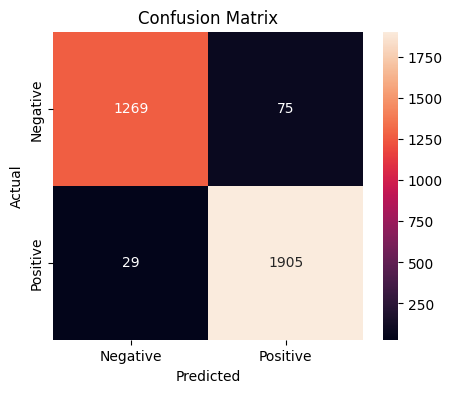

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [52]:
from sklearn.metrics import classification_report

pred_output = trainer.predict(dataset["test"])

y_true = pred_output.label_ids
y_pred = pred_output.predictions.argmax(axis=1)

report = classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Positive"],
    digits=2
)

print(report)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


              precision    recall  f1-score   support

    Negative       0.98      0.94      0.96      1344
    Positive       0.96      0.99      0.97      1934

    accuracy                           0.97      3278
   macro avg       0.97      0.96      0.97      3278
weighted avg       0.97      0.97      0.97      3278



In [53]:
model.save_pretrained("./camel_binary_model")
tokenizer.save_pretrained("./camel_binary_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./camel_binary_model/tokenizer_config.json',
 './camel_binary_model/tokenizer.json')